In [1]:
print("heklo")

heklo


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

#assumtion 


#algorithm
from sklearn.linear_model import LinearRegression

#train test
from sklearn.model_selection import train_test_split


## data gathering

In [ ]:
df=pd.read_csv(r"C:\Users\HP\Downloads\Telegram Desktop\housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

### EDA

In [5]:
df=df.drop("Address",axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [7]:
df.isna().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### Assumtion

In [9]:
df.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


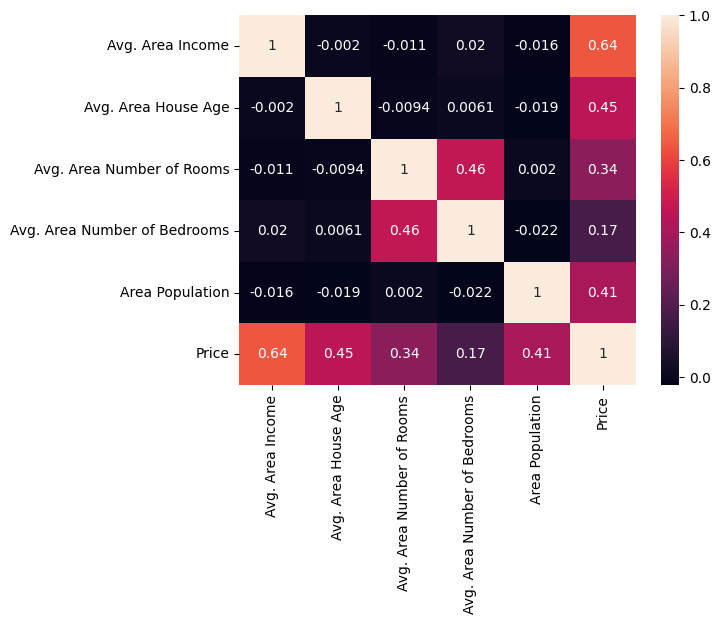

In [10]:
sns.heatmap(df.corr(),annot=True)
plt.show()

### No multicolinearity

In [11]:
df1=df.drop("Price",axis=1)

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [13]:
for i in range(df1.shape[1]):
    vif=variance_inflation_factor(df1.to_numpy(),1)
    print(vif)

27.447774723413353
27.447774723413353
27.447774723413353
27.447774723413353
27.447774723413353


In [14]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [ ]:
df1 = df1.drop('Age', axis=1)

In [ ]:
for i in range(df1.shape[1]):
    vif = variance_inflation_factor(df1.values, i)
    print(vif)

29.650899077376636
27.447774723413353
45.25729077703332
14.537873332924557
12.825450184040067


In [ ]:
df1 = df1.drop('Avg. Area Number of Rooms', axis=1)


In [ ]:
for i in range(df1.shape[1]):
    vif = variance_inflation_factor(df1.values, i)
    print(vif)

16.073052254926562
9.682676633666768
11.16140424424574


In [ ]:
df1 = df1.drop('Avg. Area House Age', axis=1)

In [ ]:
for i in range(df1.shape[1]):
    vif = variance_inflation_factor(df1.values, i)
    print(vif)

16.073052254926562
9.682676633666768
11.16140424424574


In [21]:
X = df1
y = df['Price']

### Train test

In [16]:
from sklearn.model_selection import train_test_split

In [ ]:

X = df1
y = df['Price']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

### Linear regression

In [24]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
Y_pred=model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score
print(r2_score(y_test,Y_pred))

0.9179971706985317


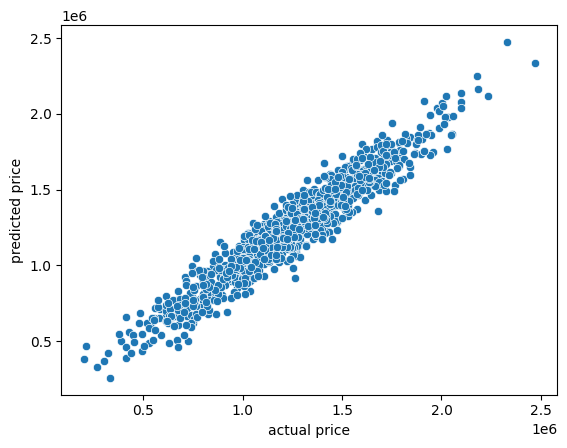

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=y_test,y=Y_pred)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.show()